# ChEBI Test Dataset EDA

This notebook performs an Exploratory Data Analysis (EDA) on the ChEBI test dataset (`chebi_dataset_test_empty.parquet`). The goal is to understand the chemical space of the molecules we need to predict classes for.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen
import os

# Set style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## 1. Load and Inspect Data

In [2]:
test_path = 'data/chebi_dataset_test_empty.parquet'
train_path = 'data/chebi_dataset_train.parquet'

df_test = pd.read_parquet(test_path)
df_train = pd.read_parquet(train_path)

print(f"Test set shape: {df_test.shape}")
print(f"Test set columns: {df_test.columns.tolist()}")
display(df_test.head())

Test set shape: (11223, 2)
Test set columns: ['mol_id', 'SMILES']


,mol_id,SMILES
0,mol_6861,OC[C@H]1O[C@H](O[C@H]2C(O)O[C@H](CO)[C@@H](O)[...
1,mol_29793,O.O=C([O-])CC(O)(CC(=O)[O-])C(=O)[O-].[K+].[K+...
2,mol_26953,CC(C)=CCC/C(C)=C/CC/C(C)=C/CC/C(C)=C\CC/C(C)=C...
3,mol_26053,C=C1CCC(C(C)C)CC1
4,mol_18653,O=C(O)C1CCCCC1=O


## 2. Molecular Property Analysis

We will calculate basic molecular properties using RDKit for the molecules in the test set.

In [3]:
def get_molecular_props(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return {
                'MW': Descriptors.MolWt(mol),
                'LogP': Crippen.MolLogP(mol),
                'H_Donors': Descriptors.NumHDonors(mol),
                'H_Acceptors': Descriptors.NumHAcceptors(mol),
                'SMILES_len': len(smiles)
            }
    except Exception as e:
        return None
    return None

print("Calculating properties for test set...")
test_props = df_test['SMILES'].apply(get_molecular_props).apply(pd.Series)
df_test_full = pd.concat([df_test, test_props], axis=1)

print("Calculating properties for train set (for comparison)...")
train_props = df_train['SMILES'].apply(get_molecular_props).apply(pd.Series)
df_train_full = pd.concat([df_train, train_props], axis=1)

display(df_test_full.describe())

Calculating properties for test set...


[16:09:15] WARNING: not removing hydrogen atom without neighbors
[16:09:16] WARNING: not removing hydrogen atom without neighbors
[16:09:16] WARNING: not removing hydrogen atom without neighbors
[16:09:16] WARNING: not removing hydrogen atom without neighbors
[16:09:16] WARNING: not removing hydrogen atom without neighbors
[16:09:16] WARNING: not removing hydrogen atom without neighbors
[16:09:16] WARNING: not removing hydrogen atom without neighbors
[16:09:16] WARNING: not removing hydrogen atom without neighbors
[16:09:16] WARNING: not removing hydrogen atom without neighbors
[16:09:16] Unusual charge on atom 6 number of radical electrons set to zero
[16:09:17] WARNING: not removing hydrogen atom without neighbors
[16:09:17] WARNING: not removing hydrogen atom without neighbors
[16:09:17] WARNING: not removing hydrogen atom without neighbors
[16:09:18] WARNING: not removing hydrogen atom without neighbors
[16:09:19] WARNING: not removing hydrogen atom without neighbors
[16:09:19] WAR

Calculating properties for train set (for comparison)...


[16:09:32] WARNING: not removing hydrogen atom without neighbors
[16:09:32] WARNING: not removing hydrogen atom without neighbors
[16:09:32] WARNING: not removing hydrogen atom without neighbors
[16:09:32] WARNING: not removing hydrogen atom without neighbors
[16:09:33] WARNING: not removing hydrogen atom without neighbors
[16:09:33] WARNING: not removing hydrogen atom without neighbors
[16:09:33] WARNING: not removing hydrogen atom without neighbors
[16:09:33] WARNING: not removing hydrogen atom without neighbors
[16:09:34] WARNING: not removing hydrogen atom without neighbors
[16:09:34] Unusual charge on atom 0 number of radical electrons set to zero
[16:09:36] WARNING: not removing hydrogen atom without neighbors
[16:09:36] WARNING: not removing hydrogen atom without neighbors
[16:09:36] WARNING: not removing hydrogen atom without neighbors
[16:09:36] WARNING: not removing hydrogen atom without neighbors
[16:09:36] WARNING: not removing hydrogen atom without neighbors
[16:09:36] WAR

,MW,LogP,H_Donors,H_Acceptors,SMILES_len
count,11223.000000,11223.000000,11223.000000,11223.000000,11223.000000
mean,445.711149,1.576257,3.896997,7.487036,72.800677
std,428.824390,5.387242,6.175700,10.403685,85.114252
min,1.008000,-55.089700,0.000000,0.000000,1.000000
25%,215.252000,-0.652900,1.000000,3.000000,29.000000
50%,342.297000,1.808000,2.000000,5.000000,50.000000
75%,525.640500,4.241100,5.000000,9.000000,88.000000
max,8675.682000,33.982400,132.000000,230.000000,1661.000000


## 3. Visualizations

Comparing the distributions of molecular properties between training and test sets.

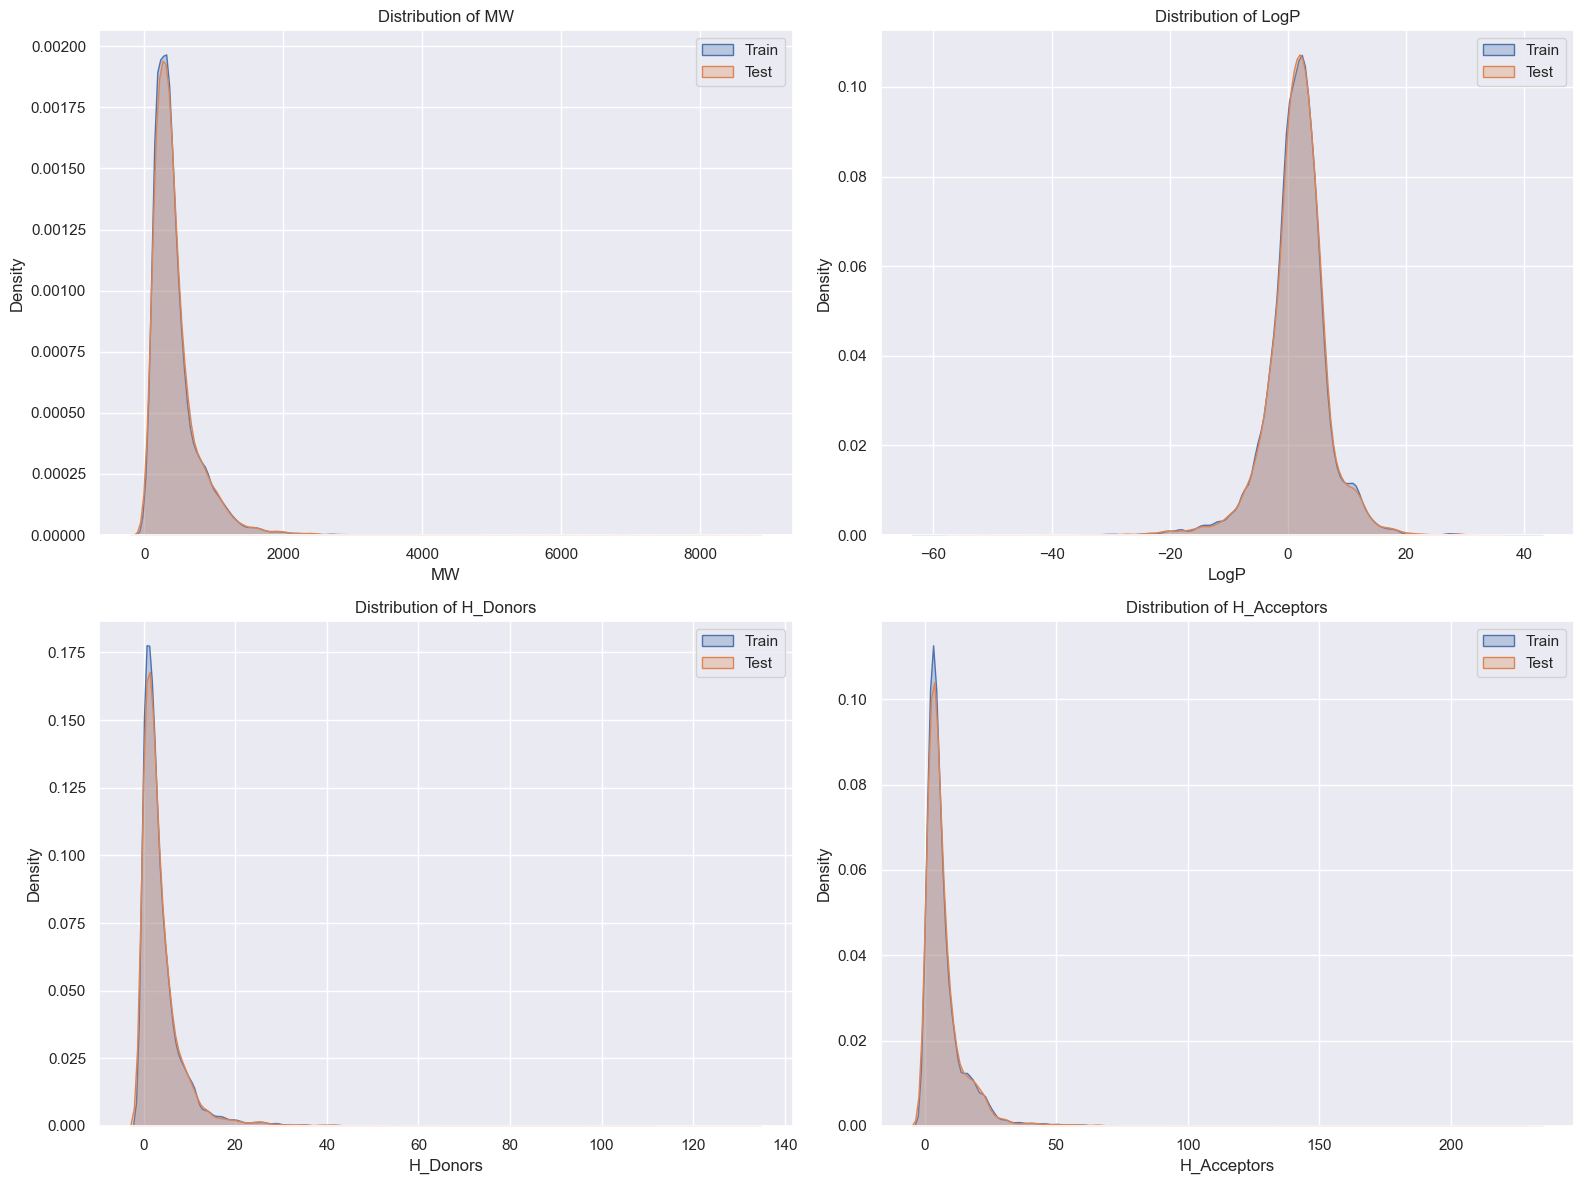

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
properties = ['MW', 'LogP', 'H_Donors', 'H_Acceptors']
colors = ['#4C72B0', '#DD8452']

for i, prop in enumerate(properties):
    ax = axes[i // 2, i % 2]
    sns.kdeplot(data=df_train_full, x=prop, ax=ax, label='Train', fill=True, alpha=0.3, color=colors[0])
    sns.kdeplot(data=df_test_full, x=prop, ax=ax, label='Test', fill=True, alpha=0.3, color=colors[1])
    ax.set_title(f'Distribution of {prop}')
    ax.legend()

plt.tight_layout()
plt.show()

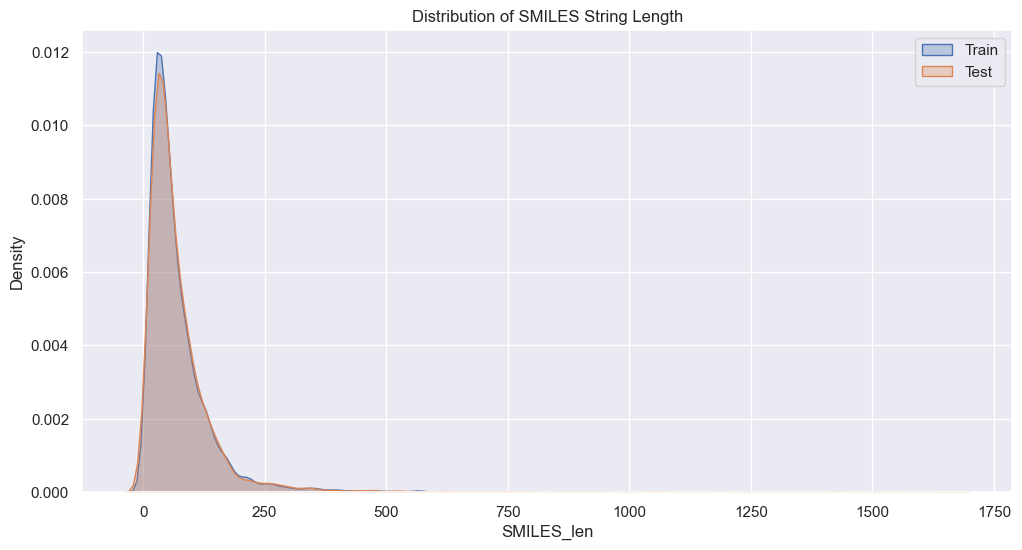

In [5]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_train_full, x='SMILES_len', label='Train', fill=True, alpha=0.3, color=colors[0])
sns.kdeplot(data=df_test_full, x='SMILES_len', label='Test', fill=True, alpha=0.3, color=colors[1])
plt.title('Distribution of SMILES String Length')
plt.legend()
plt.show()